In [157]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.loc'] = 'best'

plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 8  # Taille des labels des xticks
plt.rcParams['ytick.labelsize'] = 8  # Taille des labels des yticks
plt.rcParams['legend.fontsize'] = 8 # Taille des labels de la légende
plt.rcParams['figure.titlesize'] = 12  # Taille du titre de la figure
plt.rcParams['axes.titlesize'] = 12  # Taille du titre des sous-graphes
plt.rcParams['axes.labelsize'] = 10  # Taille des labels des axes







path="/media/nicolascatz/ssdcalcul/Projets/M1_NEURO_APP_NC"
path="D:/DATA/Projets/M1_NEURO_APP_NC"

pathresults=path+"/out/"
pathscripts=path+"/scripts/"

file=np.load(pathresults+"FileAll.npz", allow_pickle=True)["arr_0"]
unit=np.load(pathresults+"UnitAll.npz", allow_pickle=True)["arr_0"]

In [158]:
print(unit.shape)
print("nb of units: ", file.shape[0])


(918,)
nb of units:  918


In [358]:
nbunits = unit.shape[0]
nbunits

918

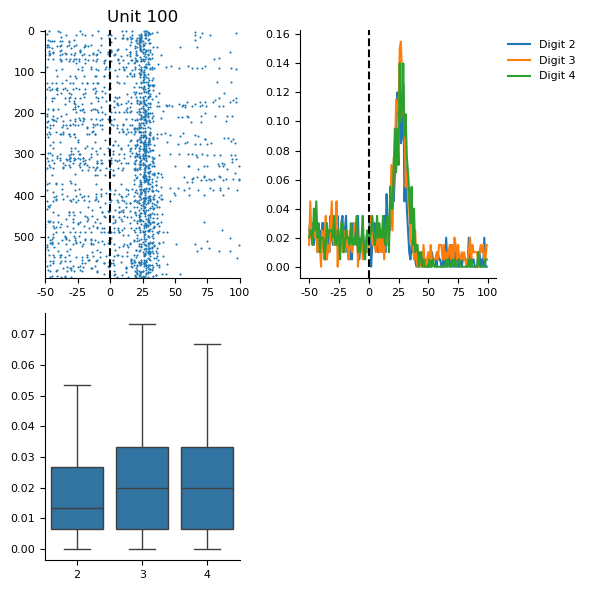

In [334]:
import scipy.stats as stats
import seaborn as sns


n=100

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6,6))
ax_flat = ax.flatten()

ax_flat[0].spy(unit[n][:,50:200],aspect='auto',markersize=0.5)
ax_flat[0].xaxis.set_ticks_position('bottom')
ax_flat[0].axvline(x=50, color='k', linestyle='--')
ax_flat[0].set_title("Unit "+str(n))
ax_flat[0].set_xticks([0,25,50,75,100,125,150])
ax_flat[0].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])

ax_flat[1].plot(unit[n][unit[n][:,0]==2][:,50:200].mean(axis=0), label="Digit 2")
ax_flat[1].plot(unit[n][unit[n][:,0]==3][:,50:200].mean(axis=0), label="Digit 3")
ax_flat[1].plot(unit[n][unit[n][:,0]==4][:,50:200].mean(axis=0), label="Digit 4")
ax_flat[1].legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax_flat[1].axvline(x=50, color='k', linestyle='--')

ax_flat[1].set_xticks([0,25,50,75,100,125,150])
ax_flat[1].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])

ax_flat[1].spines['right'].set_visible(False)
ax_flat[1].spines['top'].set_visible(False)




sns.boxplot(x=unit[n][:,0], y=unit[n][:,50:200].mean(axis=1), ax=ax_flat[2],showfliers=False)
ax_flat[2].spines['right'].set_visible(False)
ax_flat[2].spines['top'].set_visible(False)
ax_flat[3].axis('off')
plt.tight_layout()
plt.show()

In [364]:
import random
UnitPop=[]
for n in range(nbunits):

    unit2=unit[n][unit[n][:,0]==2][:,50:200]
    unit3=unit[n][unit[n][:,0]==3][:,50:200]
    unit4=unit[n][unit[n][:,0]==4][:,50:200]

    if unit2.shape[0] > 100 and unit3.shape[0] > 100 and unit4.shape[0] > 100:
        unit300=np.concatenate((unit2[random.sample(range(unit2.shape[0]), 100),:],
                            unit3[random.sample(range(unit3.shape[0]), 100),:],
                            unit4[random.sample(range(unit4.shape[0]), 100),:]), axis=0)
        

        UnitTime=np.sum(unit300[:,60:100], axis=1) # sum spikes in the time window

        UnitTime[UnitTime>0]=1 # binarize    


    UnitPop.extend([UnitTime])


StimTarget = [2] * 100
StimTarget.extend([3] * 100)
StimTarget.extend([4] * 100)
print(StimTarget)


[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


In [375]:
UnitPop=np.array(UnitPop.T)
print(UnitPop.shape)



(300, 918)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


X = UnitPop
y = StimTarget


# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
accuracy = []
# Créer et entraîner le modèle KNN
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred = knn.predict(X_test)

# Évaluer la performance du modèle
accuracy=accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

Accuracy: 0.26666666666666666


ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [393]:
y_pred

array([4, 4, 3, 3, 4, 4, 3, 3, 3, 3, 4, 2, 4, 2, 3, 4, 4, 4, 3, 3, 2, 3,
       4, 4, 4, 2, 4, 4, 4, 4, 2, 4, 3, 2, 4, 3, 2, 2, 2, 2, 2, 2, 4, 2,
       3, 2, 4, 4, 3, 4, 3, 3, 4, 3, 3, 4, 3, 2, 3, 2])

In [396]:
np.transpose(y_test)

array([4, 4, 3, 2, 4, 4, 3, 3, 2, 3, 4, 2, 4, 2, 3, 4, 4, 4, 3, 3, 2, 3,
       4, 4, 3, 2, 4, 4, 3, 4, 2, 3, 2, 2, 4, 3, 2, 2, 2, 2, 2, 2, 4, 2,
       2, 2, 4, 4, 3, 4, 3, 3, 4, 2, 4, 4, 2, 2, 3, 2])

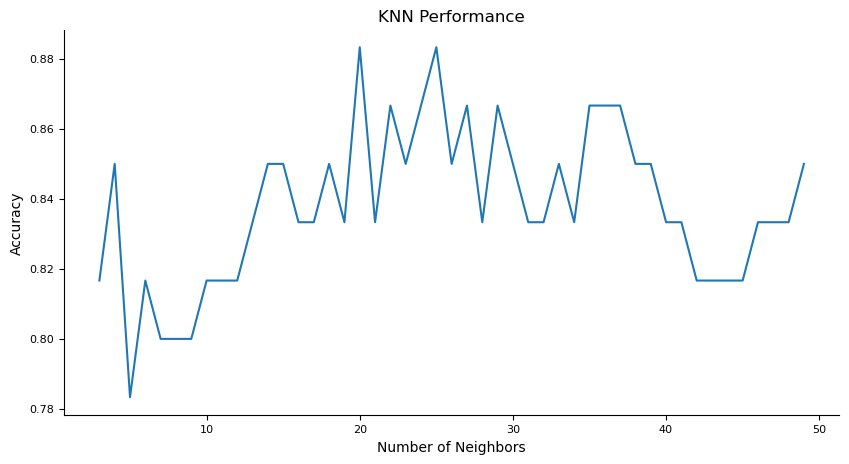

In [389]:
plt.plot(range(3,50), accuracy)
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('KNN Performance')
plt.show()

In [391]:
np.sqrt(300)

17.320508075688775